<a href="https://colab.research.google.com/github/weloo11/mnist-image-classifier/blob/main/mlp1(HOG).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Image data shape: (70000, 28, 28)
Label shape: (70000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


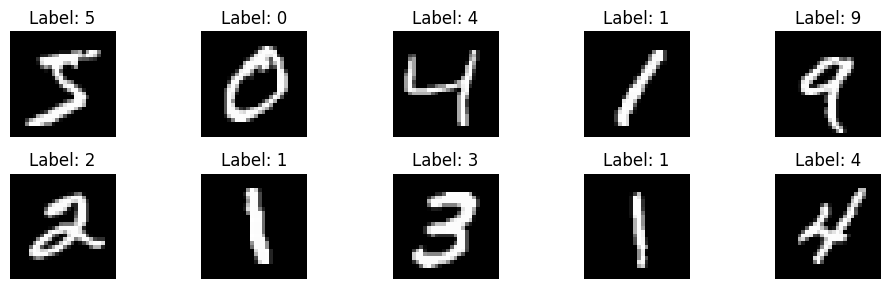

Target digit: 5
Positive samples: 6313
Negative samples: 63687
Positive ratio: 0.09018571428571429
Negative ratio: 0.9098142857142857
Min pixel value: 0.0
Max pixel value: 1.0
Train shape: (49000, 28, 28) (49000,)
Validation shape: (10500, 28, 28) (10500,)
Test shape: (10500, 28, 28) (10500,)
Training set:
  Positives = 4419 (0.0902)
  Negatives = 44581 (0.9098)
Validation set:
  Positives = 947 (0.0902)
  Negatives = 9553 (0.9098)
Test set:
  Positives = 947 (0.0902)
  Negatives = 9553 (0.9098)
HOG feature length for one image: 1296
HOG training shape: (49000, 1296)
HOG validation shape: (10500, 1296)
HOG test shape: (10500, 1296)
Preprocessing complete with HOG.
Scaled HOG training shape: (49000, 1296)
Scaled HOG validation shape: (10500, 1296)
Scaled HOG test shape: (10500, 1296)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog

# 1) Choose target digit
TARGET_DIGIT = 5

# 2) Load MNIST
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# 3) Combine full dataset
X = np.concatenate([X_train_full, X_test_full], axis=0)
y = np.concatenate([y_train_full, y_test_full], axis=0)

# 4) Inspect shapes
print("Image data shape:", X.shape)
print("Label shape:", y.shape)
print("Unique labels:", np.unique(y))

# 5) Show sample images
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 6) Convert labels to binary: target vs not target
y_binary = (y == TARGET_DIGIT).astype(int)

# 7) Check class distribution
num_positive = np.sum(y_binary == 1)
num_negative = np.sum(y_binary == 0)

print("Target digit:", TARGET_DIGIT)
print("Positive samples:", num_positive)
print("Negative samples:", num_negative)
print("Positive ratio:", num_positive / len(y_binary))
print("Negative ratio:", num_negative / len(y_binary))

# 8) Normalize pixel values to [0,1]
X = X.astype("float32") / 255.0

print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

# 9) Split into train and temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_binary,
    test_size=0.30,
    random_state=42,
    stratify=y_binary
)

# 10) Split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

# 11) Check distribution in each split
def print_class_distribution(name, labels):
    positives = np.sum(labels == 1)
    negatives = np.sum(labels == 0)
    total = len(labels)
    print(f"{name}:")
    print(f"  Positives = {positives} ({positives/total:.4f})")
    print(f"  Negatives = {negatives} ({negatives/total:.4f})")

print_class_distribution("Training set", y_train)
print_class_distribution("Validation set", y_val)
print_class_distribution("Test set", y_test)

# 12) HOG feature extraction
def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        hog_features.append(features)
    return np.array(hog_features)

# Optional test on one image
sample_hog = hog(
    X_train[0],
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm='L2-Hys'
)
print("HOG feature length for one image:", len(sample_hog))

# Extract HOG features for each split
X_train_hog = extract_hog_features(X_train)
X_val_hog   = extract_hog_features(X_val)
X_test_hog  = extract_hog_features(X_test)

print("HOG training shape:", X_train_hog.shape)
print("HOG validation shape:", X_val_hog.shape)
print("HOG test shape:", X_test_hog.shape)

# 13) Standardize HOG features
hog_scaler = StandardScaler()
X_train_hog_scaled = hog_scaler.fit_transform(X_train_hog)
X_val_hog_scaled   = hog_scaler.transform(X_val_hog)
X_test_hog_scaled  = hog_scaler.transform(X_test_hog)

print("Preprocessing complete with HOG.")
print("Scaled HOG training shape:", X_train_hog_scaled.shape)
print("Scaled HOG validation shape:", X_val_hog_scaled.shape)
print("Scaled HOG test shape:", X_test_hog_scaled.shape)

In [ ]:
# Save HOG features
np.save("X_train_hog.npy", X_train_hog_scaled)
np.save("X_val_hog.npy", X_val_hog_scaled)
np.save("X_test_hog.npy", X_test_hog_scaled)

# Save labels
np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

print("HOG features and labels saved as .npy files.")

HOG features and labels saved as .npy files.
